## Comparing uncertainity calculated from committee in energies and forces on valid.xyz and a90_gb_subset500.xyz dataset

In [1]:
import time

t0 = time.time()
import json
print("json import:", time.time() - t0)

t0 = time.time()
import pandas as pd
print("pandas import:", time.time() - t0)

t0 = time.time()
import plotly.graph_objects as go
print("plotly import:", time.time() - t0)

t0 = time.time()
with open("/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/a90_gb_subset500_stats.json") as f:
    data = json.load(f)
print("json load:", time.time() - t0, "| n_entries:", len(data))

json import: 8.296966552734375e-05
pandas import: 0.351254940032959
plotly import: 0.0037224292755126953
json load: 0.0021533966064453125 | n_entries: 500


In [2]:
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os

# ============ PLACEHOLDERS: update these paths ============
VALID_JSON_PATH = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/valid_committee_stats.json"
GB_JSON_PATH = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/a90_gb_subset500_stats.json"
GB_LABEL = "a90_gb_subset500"
OUTPUT_DIR = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/comparison_valid_a90"
# ============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(VALID_JSON_PATH) as f:
    valid_data = json.load(f)
with open(GB_JSON_PATH) as f:
    gb_data = json.load(f)

df_valid = pd.DataFrame(valid_data)
df_valid["set"] = "valid"
df_gb = pd.DataFrame(gb_data)
df_gb["set"] = GB_LABEL

df_all = pd.concat([df_valid, df_gb], ignore_index=True)
df_all.to_csv(f"{OUTPUT_DIR}/combined_committee_stats.csv", index=False)

# ---- 1. Summary statistics ----
summary_rows = []
for set_name, df in [("valid", df_valid), (GB_LABEL, df_gb)]:
    for col in ["std_energy", "mean_force", "mean_std_force"]:
        vals = df[col].values
        summary_rows.append({
            "set": set_name, "metric": col,
            "mean": np.mean(vals), "median": np.median(vals),
            "std": np.std(vals), "min": np.min(vals), "max": np.max(vals),
            "n": len(vals),
        })
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f"{OUTPUT_DIR}/summary_stats.csv", index=False)
print(df_summary.to_string(index=False))

print(" CSVs written to", OUTPUT_DIR)

             set         metric     mean   median      std      min      max   n
           valid     std_energy 0.269385 0.272344 0.016641 0.213988 0.300190  45
           valid     mean_force 0.659062 0.170745 0.703006 0.150018 1.994566  45
           valid mean_std_force 0.008822 0.005460 0.006118 0.002613 0.025810  45
a90_gb_subset500     std_energy 0.256091 0.255489 0.029484 0.173614 0.362335 500
a90_gb_subset500     mean_force 0.673173 0.675294 0.049743 0.534624 0.897355 500
a90_gb_subset500 mean_std_force 0.013673 0.013441 0.001596 0.010287 0.019700 500
 CSVs written to /home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/comparison_valid_a90


## Plotting

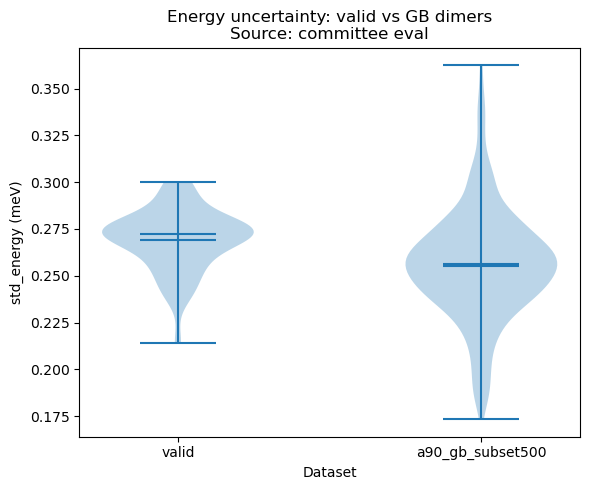

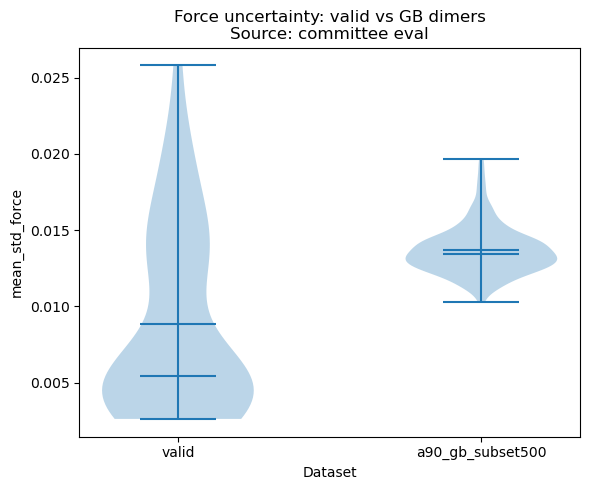

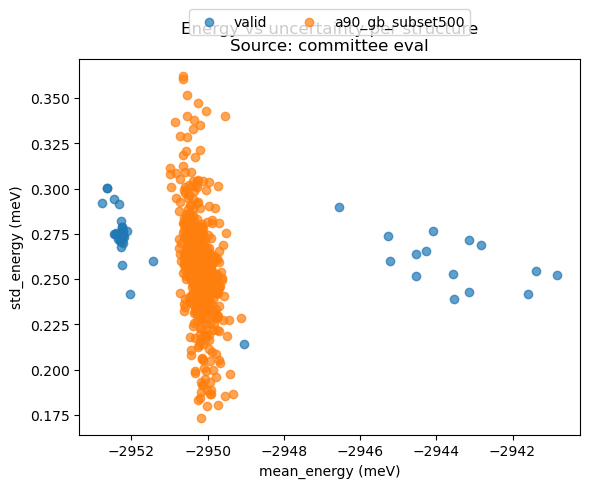

In [4]:
import matplotlib.pyplot as plt

# ---- 2. Violin: std_energy ----
fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.violinplot([df_valid["std_energy"], df_gb["std_energy"]],
               showmeans=True, showmedians=True)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(["valid", GB_LABEL])
ax1.set_ylabel("std_energy (meV)")
ax1.set_xlabel("Dataset")
ax1.set_title("Energy uncertainty: valid vs GB dimers\nSource: committee eval")
fig1.tight_layout()
plt.show()

# ---- 3. Violin: mean_std_force ----
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.violinplot([df_valid["mean_std_force"], df_gb["mean_std_force"]],
               showmeans=True, showmedians=True)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(["valid", GB_LABEL])
ax2.set_ylabel("mean_std_force")
ax2.set_xlabel("Dataset")
ax2.set_title("Force uncertainty: valid vs GB dimers\nSource: committee eval")
fig2.tight_layout()
plt.show()

# ---- 4. Scatter: mean_energy vs std_energy ----
fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.scatter(df_valid["mean_energy"], df_valid["std_energy"], label="valid", alpha=0.7)
ax3.scatter(df_gb["mean_energy"], df_gb["std_energy"], label=GB_LABEL, alpha=0.7)
ax3.set_xlabel("mean_energy (meV)")
ax3.set_ylabel("std_energy (meV)")
ax3.set_title("Energy vs uncertainty per structure\nSource: committee eval")
ax3.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
fig3.tight_layout()
plt.show()

## checking a,b,c vectors of pentacene bulk unit cell to confirm rotation axes and plane normals

In [ ]:

from ase.io import read

bulk = read("/Users/sonaligarg/Desktop/Phd_data/git-repo/pentacene-gb-active-learning/data/seed_structures/pentacene_bulk.cif")
cell = bulk.get_cell()

print("a_vec:", cell[0])
print("b_vec:", cell[1])
print("c_vec:", cell[2])

a_vec: [6.2753 0.     0.    ]
b_vec: [0.73611863 7.67859621 0.        ]
c_vec: [ 0.50126143  3.27683285 14.05681405]


/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/io/cif.py:411: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(2, setting=1). This may result in wrong setting!
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 9 and 36 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 0 and 37 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 1 and 38 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 2 and 39 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/

## Check whether Jitter is applied or not
- real thermal vibrational amplitudes in organic crystals at room temperature are typically in the 0.05-0.15 Å range
- so applying jitter which is bond length alteration

In [6]:
from ase.io import read
import numpy as np

jittered = read("/Users/sonaligarg/Desktop/Phd_data/git-repo/pentacene-gb-active-learning/data/seed_structures/generated_dimers/dimer_a_axis_000deg_sep4.20_jitter_0002.xyz")

positions = jittered.get_positions()[:36]
symbols = jittered.get_chemical_symbols()[:36]

cc_bonds = []
ch_bonds = []

for i in range(36):
    for j in range(i+1, 36):
        d = np.linalg.norm(positions[i] - positions[j])
        pair = {symbols[i], symbols[j]}
        if pair == {"C"} and d < 1.6:
            cc_bonds.append(d)
        elif pair == {"C", "H"} and d < 1.2:
            ch_bonds.append(d)

cc_bonds = np.array(cc_bonds)
ch_bonds = np.array(ch_bonds)

print("C-C bonds found:", len(cc_bonds), "| mean:", cc_bonds.mean(), "| std:", cc_bonds.std())
print("C-H bonds found:", len(ch_bonds), "| mean:", ch_bonds.mean(), "| std:", ch_bonds.std())

C-C bonds found: 26 | mean: 1.4238521480120407 | std: 0.06758463289763844
C-H bonds found: 14 | mean: 1.0666350629605106 | std: 0.05243517862081512
